In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout, Concatenate
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
# PARAMETERS
data_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\datasets\feature_combined_emotion_dataset.csv"
glove_path = r"C:\Users\ronle\Desktop\BUAS\Y2C\glove.6B.300d.txt"
max_words = 10000
max_len = 100
embedding_dim = 300

In [9]:
# LOAD DATA
df = pd.read_csv(data_path)

# Create target label by taking argmax across emotion columns
emotion_cols = ['happiness', 'sadness', 'disgust', 'anger', 'fear', 'surprise', 'neutral']
df['label'] = df[emotion_cols].values.argmax(axis=1)
num_classes = len(emotion_cols)
y = to_categorical(df['label'], num_classes=num_classes)

In [10]:
# Prepare sentiment features and normalize
sentiment_features = df[['TextBlob_Polarity', 'VADER_Compound']].values
scaler = StandardScaler()
sentiment_features = scaler.fit_transform(sentiment_features)

# TOKENIZE TEXT
df['text'] = df['text'].astype(str)
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['text'])
sequences = tokenizer.texts_to_sequences(df['text'])
X_text = pad_sequences(sequences, maxlen=max_len)

In [11]:
# SPLIT DATA (70% train, 20% val, 10% test)
X_text_temp, X_text_test, X_sent_temp, X_sent_test, y_temp, y_test = train_test_split(
    X_text, sentiment_features, y, test_size=0.10, random_state=42, stratify=y)
X_text_train, X_text_val, X_sent_train, X_sent_val, y_train, y_val = train_test_split(
    X_text_temp, X_sent_temp, y_temp, test_size=0.2222, random_state=42, stratify=y_temp)

In [12]:
# LOAD PRETRAINED GLOVE EMBEDDINGS
embeddings_index = {}
with open(glove_path, encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeffs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coeffs
print(f'Found {len(embeddings_index)} word vectors in GloVe.')

Found 400000 word vectors in GloVe.


In [13]:
# CREATE EMBEDDING MATRIX
word_index = tokenizer.word_index
num_words = min(max_words, len(word_index) + 1)
embedding_matrix = np.zeros((num_words, embedding_dim))
for word, i in word_index.items():
    if i >= max_words:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [18]:
# Define the model architecture
# Text branch
text_input = Input(shape=(max_len,), name='text_input')
embedding_layer = Embedding(input_dim=num_words,
                            output_dim=embedding_dim,
                            weights=[embedding_matrix],
                            input_length=max_len,
                            trainable=False)(text_input)

In [19]:
# Here we replace LSTM with SimpleRNN
rnn_out = SimpleRNN(128, dropout=0.2, recurrent_dropout=0.2)(embedding_layer)

# Sentiment branch
sent_input = Input(shape=(sentiment_features.shape[1],), name='sentiment_input')
sent_dense = Dense(32, activation='relu')(sent_input)
sent_dense = Dropout(0.3)(sent_dense)

# Combine branches
combined = Concatenate()([rnn_out, sent_dense])
combined_dense = Dense(64, activation='relu')(combined)
combined_dense = Dropout(0.5)(combined_dense)
output = Dense(num_classes, activation='softmax')(combined_dense)

# Build and compile the RNN model
rnn_model = Model(inputs=[text_input, sent_input], outputs=output)
rnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
rnn_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 text_input (InputLayer)        [(None, 100)]        0           []                               
                                                                                                  
 sentiment_input (InputLayer)   [(None, 2)]          0           []                               
                                                                                                  
 embedding_1 (Embedding)        (None, 100, 300)     3000000     ['text_input[0][0]']             
                                                                                                  
 dense (Dense)                  (None, 32)           96          ['sentiment_input[0][0]']        
                                                                                              

In [20]:
# DEFINE CALLBACKS
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ModelCheckpoint(filepath='best_rnn_model.h5', monitor='val_loss', save_best_only=True)
]

# MODEL DEFINITION: Simple RNN version
# Text branch
text_input = Input(shape=(max_len,), name='text_input')


In [21]:
# TRAIN THE RNN MODEL
history_rnn = rnn_model.fit(
    {'text_input': X_text_train, 'sentiment_input': X_sent_train},
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=({'text_input': X_text_val, 'sentiment_input': X_sent_val}, y_val),
    callbacks=callbacks
)

Epoch 1/50
13465/13465 [==============================] - 880s 65ms/step - loss: 1.2715 - accuracy: 0.5410 - val_loss: 1.1006 - val_accuracy: 0.5877
Epoch 2/50
13465/13465 [==============================] - 1366s 101ms/step - loss: 1.1666 - accuracy: 0.5740 - val_loss: 1.1001 - val_accuracy: 0.5934
Epoch 3/50
13465/13465 [==============================] - 1451s 108ms/step - loss: 1.1758 - accuracy: 0.5716 - val_loss: 0.9979 - val_accuracy: 0.6394
Epoch 4/50
13465/13465 [==============================] - 1523s 113ms/step - loss: 1.0575 - accuracy: 0.6171 - val_loss: 0.8778 - val_accuracy: 0.6732
Epoch 5/50
13465/13465 [==============================] - 1576s 117ms/step - loss: 1.0731 - accuracy: 0.6159 - val_loss: 0.9070 - val_accuracy: 0.6681
Epoch 6/50
13465/13465 [==============================] - 1548s 115ms/step - loss: 1.0109 - accuracy: 0.6402 - val_loss: 0.9423 - val_accuracy: 0.6590
Epoch 7/50
13465/13465 [==============================] - 1107s 82ms/step - loss: 0.9923 - accur

In [22]:
# EVALUATE ON TEST SET
loss_rnn, acc_rnn = rnn_model.evaluate({'text_input': X_text_test, 'sentiment_input': X_sent_test}, y_test)
print(f'RNN Test Loss: {loss_rnn:.4f} / Test Accuracy: {acc_rnn:.4f}')

1924/1924 [==============================] - 168s 87ms/step - loss: 0.7303 - accuracy: 0.7354
RNN Test Loss: 0.7303 / Test Accuracy: 0.7354


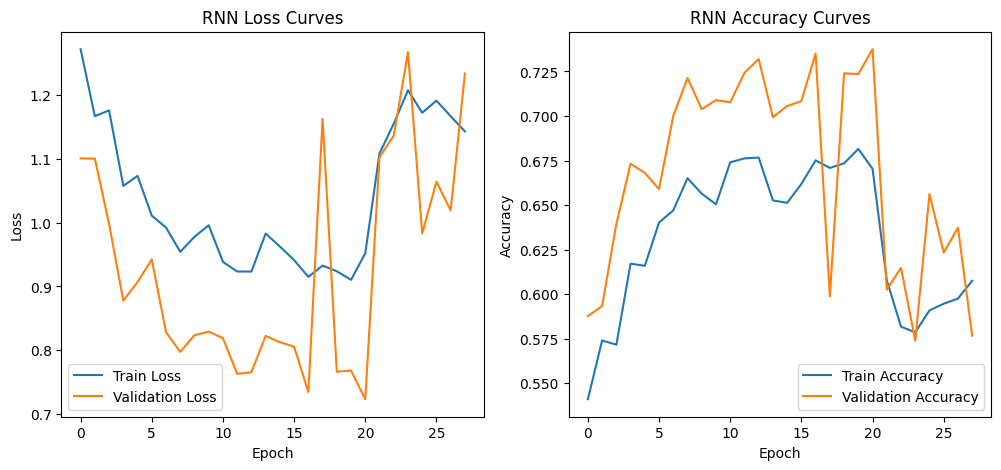

1924/1924 [==============================] - 92s 48ms/step


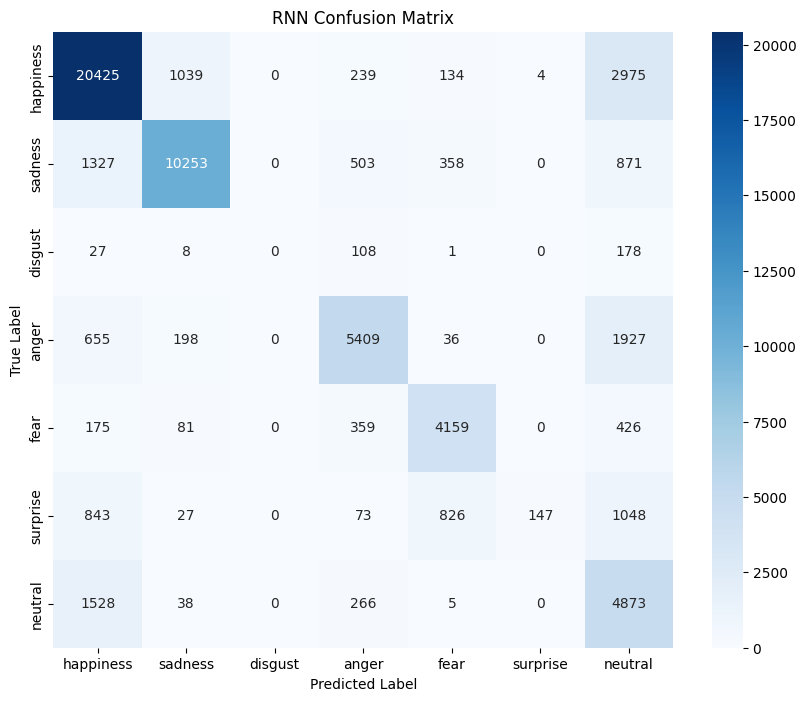

RNN Classification Report:
              precision    recall  f1-score   support

   happiness       0.82      0.82      0.82     24816
     sadness       0.88      0.77      0.82     13312
     disgust       0.00      0.00      0.00       322
       anger       0.78      0.66      0.71      8225
        fear       0.75      0.80      0.78      5200
    surprise       0.97      0.05      0.09      2964
     neutral       0.40      0.73      0.51      6710

    accuracy                           0.74     61549
   macro avg       0.66      0.55      0.53     61549
weighted avg       0.78      0.74      0.73     61549



c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ronle\anaconda3\envs\y2c\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
# 1. Learning Curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('RNN Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('RNN Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 2. Confusion Matrix
# Get predictions from the RNN model
y_pred_rnn = rnn_model.predict({'text_input': X_text_test, 'sentiment_input': X_sent_test})
y_pred_rnn_classes = np.argmax(y_pred_rnn, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_rnn_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_cols, yticklabels=emotion_cols)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('RNN Confusion Matrix')
plt.show()

# 3. Classification Report
print("RNN Classification Report:")
print(classification_report(y_true, y_pred_rnn_classes, target_names=emotion_cols))


In [25]:
rnn_model.save('RNN_2.h5')

In [24]:
# ... existing code ...

# Print overall metrics
print("\nOverall Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Add confusion matrix using the same variables as in cell 12
y_pred_rnn = rnn_model.predict({'text_input': X_text_test, 'sentiment_input': X_sent_test})
y_pred_rnn_classes = np.argmax(y_pred_rnn, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_rnn_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_cols, yticklabels=emotion_cols)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('RNN Confusion Matrix')
plt.show()

# Print confusion matrix as text
print("\nConfusion Matrix:")
print(cm)
# ... existing code ...


Overall Metrics:


NameError: name 'accuracy' is not defined